# 1. Are more memorable images more likely to be remembered in this task?

In [11]:
import os, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

""" 
notes:
1. orange_chosen = 2 -> orange, orange_chosen=1 -> blue
2. old_deck = 0.5 -> orange, old_deck = -0.5 -> blue
"""
# print(beh.columns)

data_path = 'task2Data.csv'
beh = pd.read_csv(data_path, index_col=0)
old_trials = beh[beh.old_value.notna()].copy()

# old_deck encodes which side contained the old item:
#   -0.5 -> blue object was old
#    0.5 -> orange object was old
old_trials['old_object'] = np.where(
    old_trials['old_deck'] == -0.5,
    old_trials['blue_object'],
    old_trials['orange_object']
)

# Extract the numeric object ID from strings like object123.jpg.
old_trials['old_object_id'] = (
    old_trials['old_object']
    .str.extract(r'(\d+)')[0]
    .astype(float)
    .astype('Int64')
)
# old_trials[['orange_object', 'blue_object', 'old_deck', 'old_object', 'old_object_id']].head()

In [14]:
##### MEMNET VERSION
# mem = pd.read_csv('./../../../hybrid_rl/fmri_analysis/data/objects.csv')
# mem = mem[mem.dataset=='jonathan'].drop(columns=['dataset']).reset_index(drop=True)
# mem['object_id'] = mem['obj_id']


### RESMEM VERSION
mem = pd.read_csv('resmem_scores.csv')
mem_lookup = mem.set_index('object_id')['memscore']
mem_lookup.head()

# add to data
old_trials['old_memscore'] = old_trials['old_object_id'].map(mem_lookup)

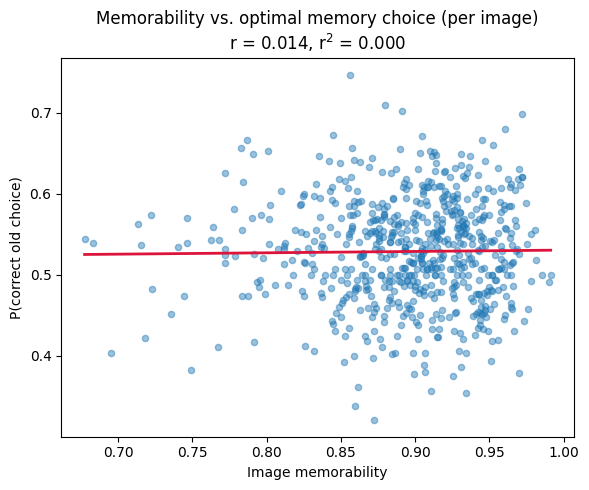

r = 0.0137
r^2 = 0.0002


In [15]:
# Average optimal old-choice performance for each object across all subjects/trials.
object_summary = (
    old_trials.groupby(['old_object_id', 'old_memscore'])['correct_old_choice']
    .mean()
    .rename('p_correct_old_choice')
    .reset_index()
)

r = object_summary['old_memscore'].corr(object_summary['p_correct_old_choice'])
r2 = r ** 2

# Plot memorability against probability of making the optimal memory-guided choice.
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(object_summary['old_memscore'], object_summary['p_correct_old_choice'], alpha=0.45, s=20)

slope, intercept = np.polyfit(object_summary['old_memscore'],object_summary['p_correct_old_choice'], 1)
x = np.linspace(object_summary['old_memscore'].min(), object_summary['old_memscore'].max(), 200)
ax.plot(x, slope * x + intercept, color='crimson', linewidth=2)

ax.set_xlabel('Image memorability')
ax.set_ylabel('P(correct old choice)')
ax.set_title(f'Memorability vs. optimal memory choice (per image)\nr = {r:.3f}, r$^2$ = {r2:.3f}')
plt.tight_layout()
plt.show()

print(f'r = {r:.4f}')
print(f'r^2 = {r2:.4f}')

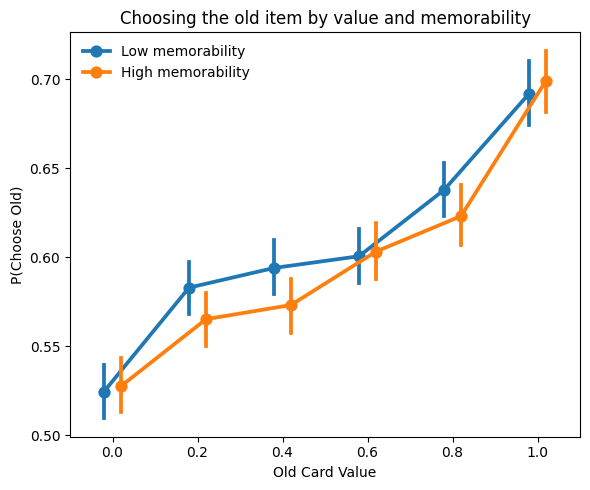

In [16]:
# Median split on old-item memorability.
median_mem = old_trials['old_memscore'].median()
old_trials['mem_group'] = np.where(
    old_trials['old_memscore'] >= median_mem,
    'High memorability',
    'Low memorability'
)

plot_df = old_trials.dropna(subset=['old_value', 'old_chosen', 'mem_group']).copy()

fig, ax = plt.subplots(figsize=(6, 5))
sns.pointplot(
    data=plot_df,
    x='old_value',
    y='old_chosen',
    hue='mem_group',
    estimator=np.mean,
    errorbar=('ci', 95),
    dodge=0.2,
    markers='o',
    linestyles='-',
    ax=ax,
)

ax.set_xlabel('Old Card Value')
ax.set_ylabel('P(Choose Old)')
ax.set_title('Choosing the old item by value and memorability')
ax.legend(frameon=False, title=None)
plt.tight_layout()
plt.show()

# 2. Does memorability predict value memory in subsequent memory task?

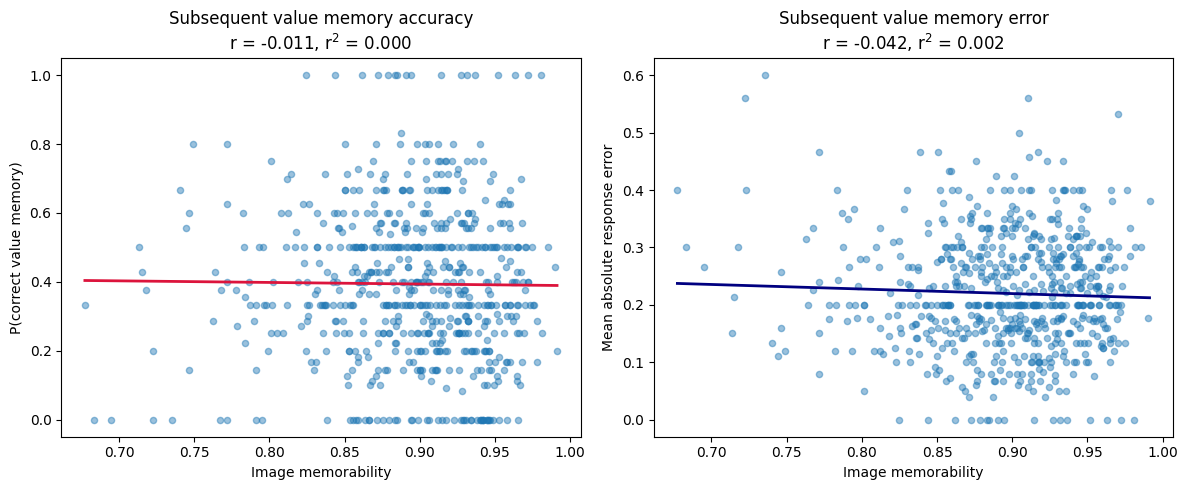

accuracy: r = -0.0110, r^2 = 0.0001
abs error: r = -0.0419, r^2 = 0.0018


In [17]:
val_mem_data = pd.read_csv('ValmemData.csv', index_col=0)
val_mem_data = val_mem_data.dropna(subset=['true_value']).copy() # exclude objects they never actually learned the value of
val_mem_data['response_error'] = (val_mem_data['response'] - val_mem_data['true_value']).abs()
val_mem_data['object_id'] = (
    val_mem_data['object']
    .str.extract(r'(\d+)')[0]
    .astype(float)
    .astype('Int64')
)
val_mem_data['old_memscore'] = val_mem_data['object_id'].map(mem_lookup)

object_valmem = (
    val_mem_data.groupby(['object_id', 'old_memscore'])
    .agg(
        p_correct=('accuracy', 'mean'),
        mean_abs_error=('response_error', 'mean'),
        n_trials=('accuracy', 'size')
    )
    .reset_index()
)

acc_r = object_valmem['old_memscore'].corr(object_valmem['p_correct'])
acc_r2 = acc_r ** 2
err_r = object_valmem['old_memscore'].corr(object_valmem['mean_abs_error'])
err_r2 = err_r ** 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy plot
axes[0].scatter(object_valmem['old_memscore'], object_valmem['p_correct'], alpha=0.45, s=20)
acc_slope, acc_intercept = np.polyfit(object_valmem['old_memscore'], object_valmem['p_correct'], 1)
x = np.linspace(object_valmem['old_memscore'].min(), object_valmem['old_memscore'].max(), 200)
axes[0].plot(x, acc_slope * x + acc_intercept, color='crimson', linewidth=2)
axes[0].set_xlabel('Image memorability')
axes[0].set_ylabel('P(correct value memory)')
axes[0].set_title(f'Subsequent value memory accuracy\nr = {acc_r:.3f}, r$^2$ = {acc_r2:.3f}')

# Error plot
axes[1].scatter(object_valmem['old_memscore'], object_valmem['mean_abs_error'], alpha=0.45, s=20)
err_slope, err_intercept = np.polyfit(object_valmem['old_memscore'], object_valmem['mean_abs_error'], 1)
axes[1].plot(x, err_slope * x + err_intercept, color='navy', linewidth=2)
axes[1].set_xlabel('Image memorability')
axes[1].set_ylabel('Mean absolute response error')
axes[1].set_title(f'Subsequent value memory error\nr = {err_r:.3f}, r$^2$ = {err_r2:.3f}')

plt.tight_layout()
plt.show()

print(f'accuracy: r = {acc_r:.4f}, r^2 = {acc_r2:.4f}')
print(f'abs error: r = {err_r:.4f}, r^2 = {err_r2:.4f}')



# 3. Is value memory reliable across subjects?

## main task data

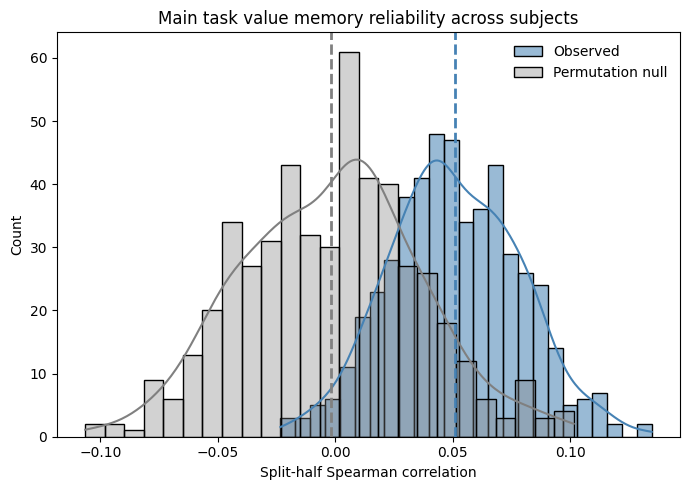

       spearman_r      null_r  spearman_brown  null_spearman_brown  n_objects
count  500.000000  500.000000      500.000000           500.000000      500.0
mean     0.050864   -0.001680        0.095492            -0.006232      654.0
std      0.027637    0.037761        0.050055             0.076013        0.0
min     -0.023347   -0.106456       -0.047810            -0.238279      654.0
25%      0.031561   -0.028344        0.061191            -0.058343      654.0
50%      0.048855    0.001609        0.093159             0.003212      654.0
75%      0.070063    0.022288        0.130951             0.043604      654.0
max      0.134736    0.101521        0.237475             0.184328      654.0
Mean observed Spearman r = 0.0509
Mean null Spearman r = -0.0017
P(observed <= 0) = 0.0340
P(observed <= null mean) = 0.0320


In [140]:
def split_half_reliability(data, subject_col, object_col, score_col, n_splits=500, seed=0):
    rng = np.random.default_rng(seed)
    subjects = np.array(sorted(data[subject_col].dropna().unique()))
    spearman_rs = []
    null_rs = []
    overlaps = []

    for _ in range(n_splits):
        shuffled = rng.permutation(subjects)
        half = len(shuffled) // 2
        split_a = shuffled[:half]
        split_b = shuffled[half:]

        mean_a = data[data[subject_col].isin(split_a)].groupby(object_col)[score_col].mean()
        mean_b = data[data[subject_col].isin(split_b)].groupby(object_col)[score_col].mean()
        merged = pd.concat([mean_a.rename('split_a'), mean_b.rename('split_b')], axis=1).dropna()

        if len(merged) > 2:
            spearman_rs.append(merged['split_a'].corr(merged['split_b'], method='spearman'))
            shuffled_b = pd.Series(rng.permutation(merged['split_b'].to_numpy()), index=merged.index)
            null_rs.append(merged['split_a'].corr(shuffled_b, method='spearman'))
            overlaps.append(len(merged))

    reliability = pd.DataFrame({'spearman_r': spearman_rs, 'null_r': null_rs, 'n_objects': overlaps})
    reliability['spearman_brown'] = 2 * reliability['spearman_r'] / (1 + reliability['spearman_r'])
    reliability['null_spearman_brown'] = 2 * reliability['null_r'] / (1 + reliability['null_r'])
    return reliability

main_reliability = split_half_reliability(
    old_trials.dropna(subset=['subject_id', 'old_object_id', 'correct_old_choice']),
    subject_col='subject_id',
    object_col='old_object_id',
    score_col='correct_old_choice',
    n_splits=500,
    seed=0,
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(main_reliability['spearman_r'], bins=25, color='steelblue', alpha=0.55, kde=True, ax=ax, label='Observed')
sns.histplot(main_reliability['null_r'], bins=25, color='gray', alpha=0.35, kde=True, ax=ax, label='Permutation null')
ax.axvline(main_reliability['spearman_r'].mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(main_reliability['null_r'].mean(), color='gray', linestyle='--', linewidth=2)
ax.set_xlabel('Split-half Spearman correlation')
ax.set_ylabel('Count')
ax.set_title('Main task value memory reliability across subjects')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(main_reliability[['spearman_r', 'null_r', 'spearman_brown', 'null_spearman_brown', 'n_objects']].describe())
print(f"Mean observed Spearman r = {main_reliability['spearman_r'].mean():.4f}")
print(f"Mean null Spearman r = {main_reliability['null_r'].mean():.4f}")
print(f"P(observed <= 0) = {(main_reliability['spearman_r'] <= 0).mean():.4f}")
print(f"P(observed <= null mean) = {(main_reliability['spearman_r'] <= main_reliability['null_r'].mean()).mean():.4f}")



## subsequent memory task

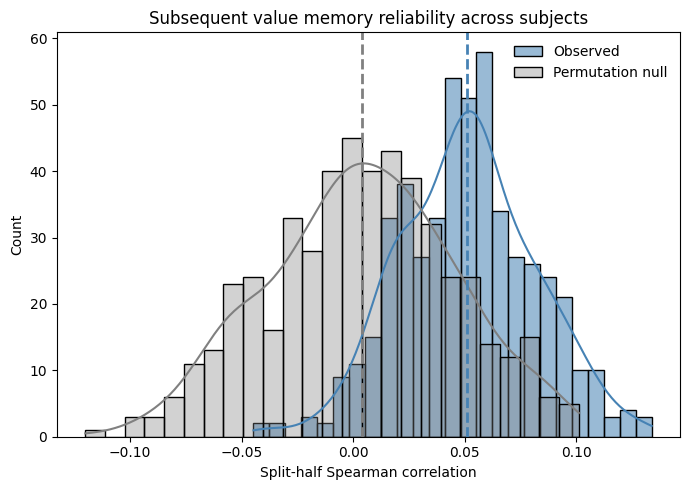

       spearman_r      null_r  spearman_brown  null_spearman_brown   n_objects
count  500.000000  500.000000      500.000000           500.000000  500.000000
mean     0.051005    0.003913        0.095475             0.004342  600.802000
std      0.030321    0.041681        0.055091             0.083478    5.721562
min     -0.044648   -0.120059       -0.093469            -0.272879  584.000000
25%      0.029290   -0.024535        0.056913            -0.050303  597.000000
50%      0.051151    0.004300        0.097324             0.008564  601.000000
75%      0.069978    0.032082        0.130802             0.062169  605.000000
max      0.133806    0.101200        0.236030             0.183800  618.000000
Mean observed Spearman r = 0.0510
Mean null Spearman r = 0.0039
P(observed <= 0) = 0.0360
P(observed <= null mean) = 0.0500


In [142]:
val_reliability = split_half_reliability(
    val_mem_data.dropna(subset=['subject_id', 'object_id', 'accuracy']),
    subject_col='subject_id',
    object_col='object_id',
    score_col='accuracy',
    n_splits=500,
    seed=0,
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(val_reliability['spearman_r'], bins=25, color='steelblue', alpha=0.55, kde=True, ax=ax, label='Observed')
sns.histplot(val_reliability['null_r'], bins=25, color='gray', alpha=0.35, kde=True, ax=ax, label='Permutation null')
ax.axvline(val_reliability['spearman_r'].mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(val_reliability['null_r'].mean(), color='gray', linestyle='--', linewidth=2)
ax.set_xlabel('Split-half Spearman correlation')
ax.set_ylabel('Count')
ax.set_title('Subsequent value memory reliability across subjects')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(val_reliability[['spearman_r', 'null_r', 'spearman_brown', 'null_spearman_brown', 'n_objects']].describe())
print(f"Mean observed Spearman r = {val_reliability['spearman_r'].mean():.4f}")
print(f"Mean null Spearman r = {val_reliability['null_r'].mean():.4f}")
print(f"P(observed <= 0) = {(val_reliability['spearman_r'] <= 0).mean():.4f}")
print(f"P(observed <= null mean) = {(val_reliability['spearman_r'] <= val_reliability['null_r'].mean()).mean():.4f}")



In [149]:
val_mem_data.head()

,subject_id,accuracy,object,response,true_value,environment_coded,response_error,object_id,old_memscore
8,70290,0,object135.jpg,0.4,0.8,raw/volstab,0.4,135,0.886498
23,70290,0,object317.jpg,0.2,1.0,raw/volstab,0.8,317,0.899676
50,70290,0,object471.jpg,0.6,0.4,raw/volstab,0.2,471,0.900042
56,70290,1,object119.jpg,0.0,0.0,raw/volstab,0.0,119,0.864739
59,70290,0,object194.jpg,0.4,0.2,raw/volstab,0.2,194,0.866684


(array([51., 33., 71., 76., 61., 71., 28., 13.,  2.,  2.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

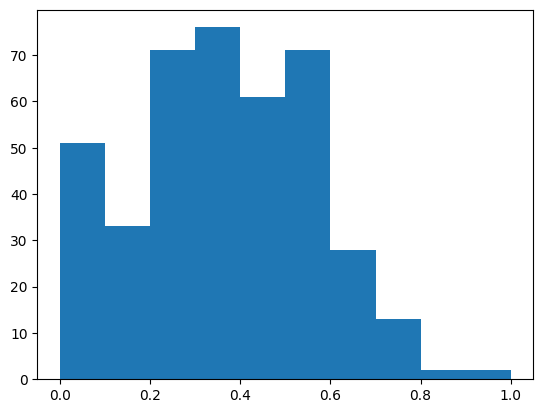

In [150]:
test = val_mem_data.groupby('subject_id')['accuracy'].mean()

plt.hist(test)